<a href="https://colab.research.google.com/github/Alemisa/Machine-Learning_Practical-Sessions/blob/main/anomaly_detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

In [51]:
df=pd.read_csv("AIS_dataset_Atlantic_01.csv")

In [52]:
df

,OBJECTID,MMSI,TrackStartTime,TrackEndTime,VesselType,Length,Width,Draft,DurationMinutes,VesselGroup
0,1,123456789,2025/01/02 14:14:38+00,2025/01/02 14:41:09+00,37.0,25.0,10.0,0.0,26,Pleasure Craft/Sailing
1,2,123456789,2025/01/02 14:45:08+00,2025/01/02 14:53:39+00,37.0,25.0,10.0,0.0,8,Pleasure Craft/Sailing
2,3,123456789,2025/01/02 14:59:09+00,2025/01/02 15:44:38+00,37.0,25.0,10.0,0.0,45,Pleasure Craft/Sailing
3,4,123456789,2025/01/02 15:57:38+00,2025/01/02 15:59:08+00,37.0,25.0,10.0,0.0,1,Pleasure Craft/Sailing
4,5,123456789,2025/01/02 16:05:08+00,2025/01/02 16:08:39+00,37.0,25.0,10.0,0.0,3,Pleasure Craft/Sailing
...,...,...,...,...,...,...,...,...,...,...
332032,332033,983192219,2025/01/05 14:06:04+00,2025/01/05 14:41:33+00,37.0,7.0,2.0,NaN,35,Pleasure Craft/Sailing
332033,332034,983568831,2025/01/25 14:20:22+00,2025/01/25 16:04:22+00,40.0,7.0,3.0,NaN,104,Passenger
332034,332035,983780008,2025/01/12 21:03:47+00,2025/01/12 21:14:17+00,37.0,5.0,2.0,NaN,10,Pleasure Craft/Sailing
332035,332036,983780008,2025/01/17 14:05:00+00,2025/01/17 15:37:34+00,37.0,5.0,2.0,NaN,92,Pleasure Craft/Sailing


In [53]:
df.shape

(332037, 10)

In [54]:
df.head()

,OBJECTID,MMSI,TrackStartTime,TrackEndTime,VesselType,Length,Width,Draft,DurationMinutes,VesselGroup
0,1,123456789,2025/01/02 14:14:38+00,2025/01/02 14:41:09+00,37.0,25.0,10.0,0.0,26,Pleasure Craft/Sailing
1,2,123456789,2025/01/02 14:45:08+00,2025/01/02 14:53:39+00,37.0,25.0,10.0,0.0,8,Pleasure Craft/Sailing
2,3,123456789,2025/01/02 14:59:09+00,2025/01/02 15:44:38+00,37.0,25.0,10.0,0.0,45,Pleasure Craft/Sailing
3,4,123456789,2025/01/02 15:57:38+00,2025/01/02 15:59:08+00,37.0,25.0,10.0,0.0,1,Pleasure Craft/Sailing
4,5,123456789,2025/01/02 16:05:08+00,2025/01/02 16:08:39+00,37.0,25.0,10.0,0.0,3,Pleasure Craft/Sailing


In [55]:
df.columns

Index(['OBJECTID', 'MMSI', 'TrackStartTime', 'TrackEndTime', 'VesselType',
       'Length', 'Width', 'Draft', 'DurationMinutes', 'VesselGroup'],
      dtype='object')

In [56]:
df['TrackStartTime'] = pd.to_datetime(df['TrackStartTime'])
df['TrackEndTime'] = pd.to_datetime(df['TrackEndTime'])

In [57]:
df['StartHour'] = df['TrackStartTime'].dt.hour
df['EndHour'] = df['TrackEndTime'].dt.hour
df['TravelTime'] = (df['TrackEndTime'] - df['TrackStartTime']).dt.seconds

In [58]:
df = df.sort_values(by=['MMSI','TrackStartTime'])

In [59]:
features = [
    'Length',
    'Width',
    'Draft',
    'DurationMinutes'
]

In [60]:
# Remove unnecessary columns.
df.drop(['OBJECTID','TrackStartTime','TrackEndTime'], axis=1, inplace=True)

In [61]:
target = 'VesselGroup'

In [62]:
encoder = LabelEncoder()

df['VesselType'] = encoder.fit_transform(df['VesselType'])
df['VesselGroup'] = encoder.fit_transform(df['VesselGroup'])
df['MMSI'] = encoder.fit_transform(df['MMSI'])

In [63]:
X = df.drop('VesselGroup', axis=1)
y = df['VesselGroup']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[features] = scaler.fit_transform(df[features])

In [66]:
import numpy as np

sequence_length = 10

X_sequences = []
y_sequences = []

In [67]:
for mmsi, vessel_data in df.groupby('MMSI'):

    vessel_data = vessel_data.reset_index(drop=True)

    for i in range(len(vessel_data) - sequence_length):

        seq = vessel_data[features].iloc[i:i+sequence_length].values
        label = vessel_data[target].iloc[i+sequence_length]

        X_sequences.append(seq)
        y_sequences.append(label)

In [68]:
X = np.array(X_sequences)
y = np.array(y_sequences)

In [69]:
print(X.shape)
print(y.shape)

(237614, 10, 4)
(237614,)


Meaning:

250000 trajectories
10 time steps
4 features

Perfect for LSTM.

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

MODEL 1 — LSTM (Trajectory Classification)

LSTM is widely used in AIS trajectory prediction and anomaly detection.

In [36]:
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

LSTM model.

In [71]:
import tensorflow as tf

model = tf.keras.Sequential()

model.add(tf.keras.layers.LSTM(
    128,
    input_shape=(X.shape[1], X.shape[2]),
    return_sequences=True
))

model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.LSTM(64))

model.add(tf.keras.layers.Dense(32, activation='relu'))

model.add(tf.keras.layers.Dense(len(np.unique(y)), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.2881 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 2/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 3/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 4/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 5/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 6/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 7/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 84s 86ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 8/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.2885 - loss: nan - val_accuracy: 0.2879 - val_loss: nan
Epoch 9/

Visualization of Trajectories

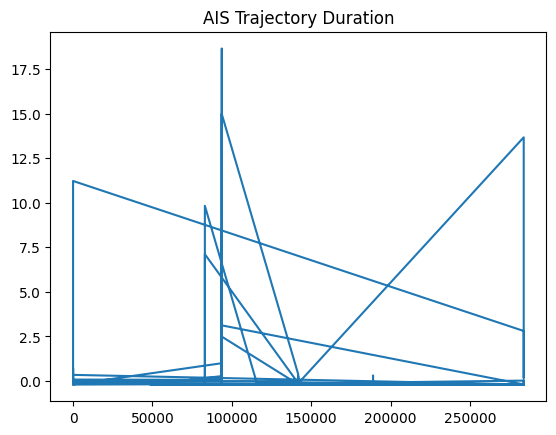

In [74]:
import matplotlib.pyplot as plt

plt.plot(df['DurationMinutes'][:500])
plt.title("AIS Trajectory Duration")
plt.show()

MODEL 2 — Autoencoder (Anomaly Detection)

Autoencoder detects abnormal vessel trajectories.

In [40]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
decoder = Dense(64, activation="relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

In [41]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

Train.

In [42]:
autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: nan - val_loss: nan
Epoch 2/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: nan - val_loss: nan
Epoch 3/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: nan - val_loss: nan
Epoch 4/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: nan - val_loss: nan
Epoch 5/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: nan - val_loss: nan
Epoch 6/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: nan - val_loss: nan
Epoch 7/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: nan - val_loss: nan
Epoch 8/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: nan - val_loss: nan
Epoch 9/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: nan - val_loss: nan
Epoch 10/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: nan - val_loss: nan
Epoch 11/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: nan - val_loss: nan
Epoch 12/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: nan - val_loss: nan
Epoch 13/20
831/831 ━━━━━━━━━━━━━━━━━

Detect anomaly.

In [43]:
reconstruction = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstruction, 2), axis=1)
threshold = np.percentile(mse, 95)
anomalies = mse > threshold

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


MODEL 3 — Transformer Model

Transformers improve long-range trajectory understanding.

In [44]:
input_layer = Input(shape=(X_train.shape[1],1))

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(input_layer, input_layer)

attention = LayerNormalization()(attention)

flatten = tf.keras.layers.Flatten()(attention)

dense = Dense(64, activation='relu')(flatten)

output = Dense(len(np.unique(y)), activation='softmax')(dense)

transformer_model = Model(inputs=input_layer, outputs=output)

Compile.

In [45]:
transformer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

MODEL 4 — Graph Neural Network (GNN)

Ships interact in maritime traffic networks.

Graph nodes = vessels
Edges = interaction between vessels

Using PyTorch Geometric

7. Model Evaluation

In [46]:
from sklearn.metrics import classification_report

pred = model_lstm.predict(X_test_lstm)

pred_class = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_class))

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
              precision    recall  f1-score   support

           0       0.25      1.00      0.40     16533
           1       0.00      0.00      0.00      4020
           2       0.00      0.00      0.00       418
           3       0.00      0.00      0.00      3853
           4       0.00      0.00      0.00     10047
           5       0.00      0.00      0.00     17371
           6       0.00      0.00      0.00      9364
           7       0.00      0.00      0.00      4802

    accuracy                           0.25     66408
   macro avg       0.03      0.12      0.05     66408
weighted avg       0.06      0.25      0.10     66408



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix.

<Axes: >

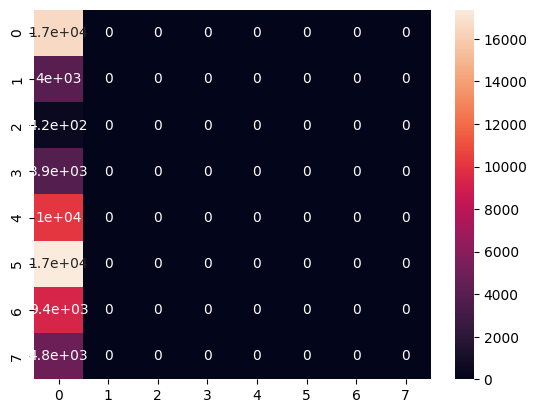

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_class)

sns.heatmap(cm, annot=True)